In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# ViT-B16

In [1]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
base_dir = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

img_dirs = [
    os.path.join(base_dir, f"images_{i:03d}", "images")
    for i in range(1, 13)
]

print(img_dirs)

['/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_002/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_004/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_005/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_006/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_007/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_008/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_009/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_010/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_011/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012/images']


In [3]:
image_index = {}

for folder in img_dirs:
    if not os.path.exists(folder):
        print("Missing:", folder)
        continue

    for file in os.listdir(folder):
        image_index[file] = os.path.join(folder, file)

print("Total images indexed:", len(image_index))

Total images indexed: 112120


In [4]:
csv_path = os.path.join(base_dir, "Data_Entry_2017.csv")

df = pd.read_csv(csv_path)

df = df[["Image Index", "Finding Labels"]]

print(df.head())

        Image Index          Finding Labels
0  00000001_000.png            Cardiomegaly
1  00000001_001.png  Cardiomegaly|Emphysema
2  00000001_002.png   Cardiomegaly|Effusion
3  00000002_000.png              No Finding
4  00000003_000.png                  Hernia


In [5]:
df["target"] = df["Finding Labels"].apply(
    lambda x: 1 if "Pneumonia" in x else 0
)

print(df["target"].value_counts())

target
0    110689
1      1431
Name: count, dtype: int64


*here we can see that there is an inbalnce in the data distribution*

In [6]:
df = df[df["Image Index"].isin(image_index.keys())].reset_index(drop=True)

print("Filtered dataset size:", len(df))

Filtered dataset size: 112120


In [7]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"],
    random_state=42
)

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [9]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["Image Index"]
        label = self.df.iloc[idx]["target"]

        img_path = image_index.get(img_name)

        if img_path is None:
            raise FileNotFoundError(f"Missing image: {img_name}")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [10]:
train_dataset = ChestXrayDataset(train_df, transform)
val_dataset = ChestXrayDataset(val_df, transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

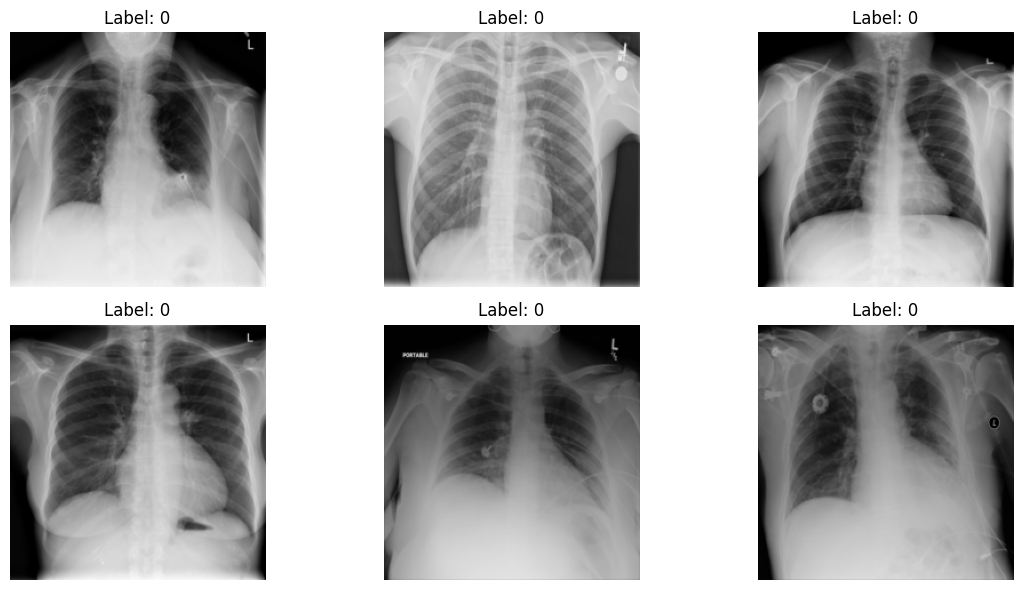

In [11]:
def show_samples(dataset, n=6):
    plt.figure(figsize=(12, 6))

    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()

        plt.subplot(2, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {int(label.item())}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

In [12]:
img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 224, 224])
tensor(0.)


In [13]:
import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("vit_base_patch16_224", pretrained=True)

model.head = nn.Linear(model.head.in_features, 1)

model = model.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [14]:
# freeze early layers only
for name, param in model.named_parameters():
    if "blocks.10" not in name and "blocks.11" not in name:
        param.requires_grad = False

In [16]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

In [17]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3)

In [18]:
def train_one_epoch():
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    return total_loss / len(train_loader)

In [19]:
def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5

            correct += (preds.squeeze() == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [20]:
for epoch in range(3):
    loss = train_one_epoch()
    acc = evaluate()

    print(f"Epoch {epoch+1}")
    print("Loss:", loss)
    print("Accuracy:", acc)

Epoch 1
Loss: 0.0690247985005081
Accuracy: 0.9872458080627898


KeyboardInterrupt: 

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla P100-PCIE-16GB


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-04-17 14:32:40.301919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776436360.491970      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776436360.545679      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776436360.987648      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776436360.987689      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776436360.987691      55 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

NameError: name 'model' is not defined

# BASIC CNN

⚙️ 1. Install & Import Libraries

In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()
print("TensorFlow:", tf.__version__)


2026-04-17 21:58:50.113175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776463130.306323      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776463130.359005      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776463130.805870      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776463130.805908      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776463130.805911      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


In [4]:
!pip install -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()
print("TensorFlow:", tf.__version__)

ERROR: You must give at least one requirement to install (see "pip help install")
TensorFlow: 2.19.0


In [5]:
DATA_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

df = pd.read_csv(os.path.join("/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"))

df['Finding Labels'] = df['Finding Labels'].apply(lambda x: x.split('|')[0])

image_folders = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.startswith("images")]

all_images = []
for folder in image_folders:
    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".png"):
                all_images.append(os.path.join(root, file))

image_dict = {os.path.basename(x): x for x in all_images}

df['path'] = df['Image Index'].map(image_dict.get)
df = df.dropna(subset=['path'])

print("Dataset size:", len(df))

Dataset size: 112120


In [6]:
df = df.copy()

if "View Position" in df.columns:
    df = df[df["View Position"].isin(["PA", "AP"])].copy()

df = df[
    (df["Finding Labels"] == "No Finding") |
    (df["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

df["label"] = df["Finding Labels"].apply(lambda x: 1 if "Pneumonia" in x else 0)
df["path"] = df["Image Index"].map(image_paths)

keep_cols = ["Image Index", "Finding Labels", "label", "path"]
if "Patient ID" in df.columns:
    keep_cols.append("Patient ID")
if "View Position" in df.columns:
    keep_cols.append("View Position")

df = df[keep_cols].dropna(subset=["path"]).drop_duplicates().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()


NameError: name 'image_paths' is not defined

In [7]:
labels = df['Finding Labels'].unique()
label_map = {label: i for i, label in enumerate(labels)}
df['label'] = df['Finding Labels'].map(label_map)

# 📊 5. EDA & Visualization

🔹 Class Distribution

label
0    60361
1      325
Name: count, dtype: int64
(60686, 14)


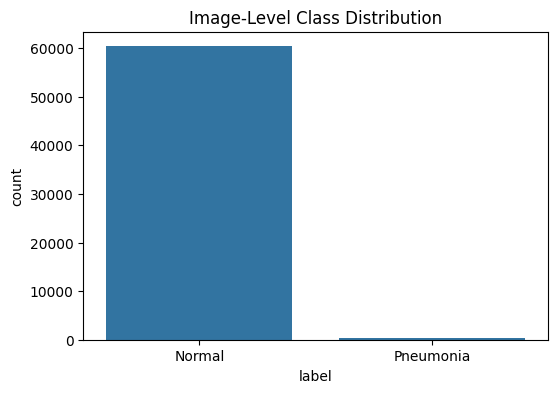

In [8]:
df_model = df.copy().reset_index(drop=True)

print(df_model["label"].value_counts())
print(df_model.shape)

plt.figure(figsize=(6, 4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Image-Level Class Distribution")
plt.show()


🔹 Image Size Distribution

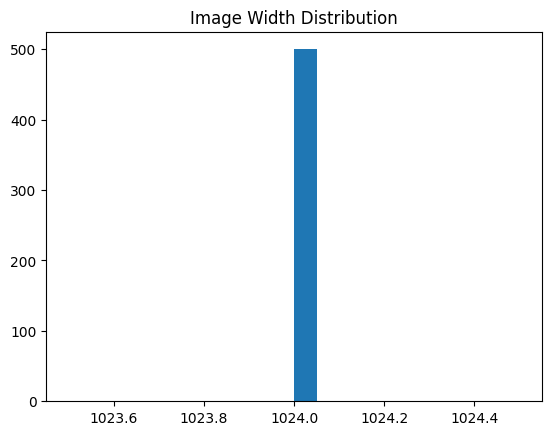

In [9]:
sizes = [Image.open(p).size for p in df['path'].sample(500)]
widths, heights = zip(*sizes)

plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

🔹 Sample Images

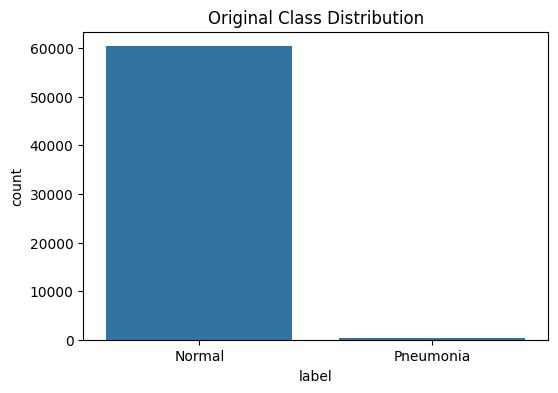

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Original Class Distribution")
plt.show()


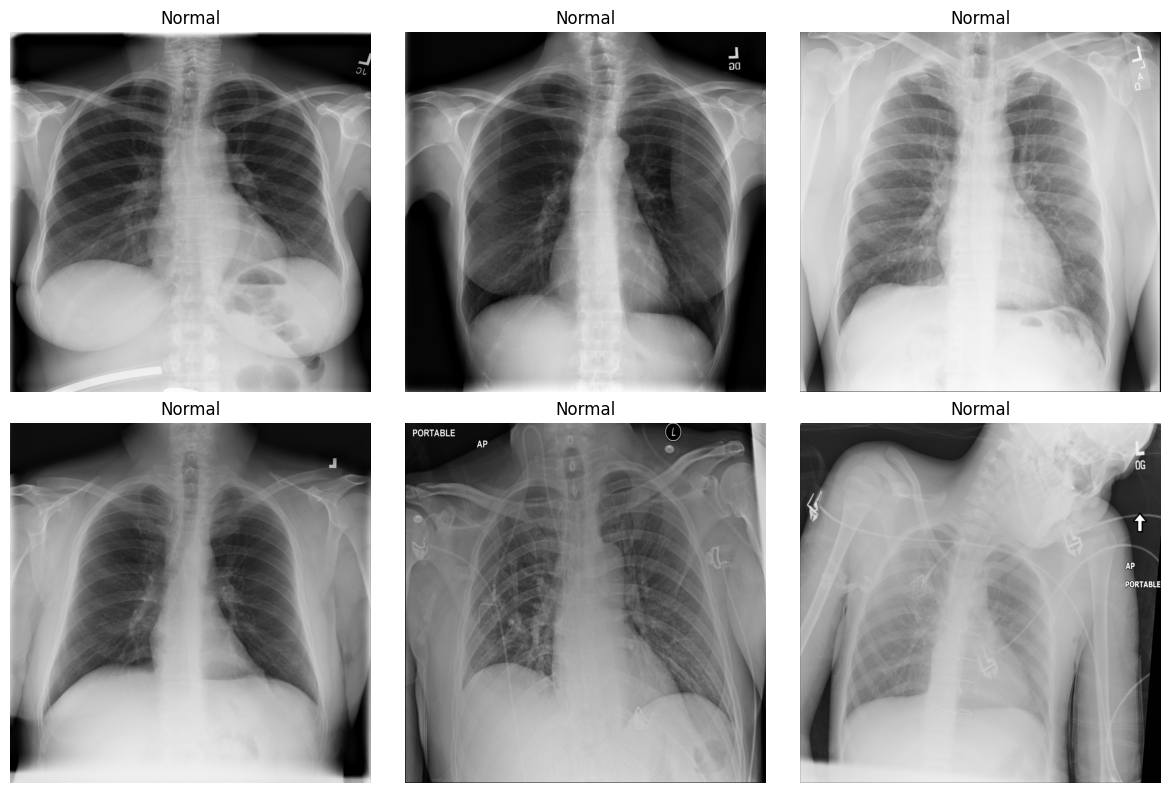

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
samples = df_model.sample(6, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img = cv2.imread(samples.loc[i, "path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Pneumonia" if samples.loc[i, "label"] == 1 else "Normal")
    ax.axis("off")

plt.tight_layout()
plt.show()


# Handle Class Imbalance

In [54]:
sizes = []

for p in df_model["path"].sample(min(200, len(df_model)), random_state=42):
    img = cv2.imread(p)
    if img is not None:
        sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])
sizes_df.describe()


,Height,Width
count,200.0,200.0
mean,1024.0,1024.0
std,0.0,0.0
min,1024.0,1024.0
25%,1024.0,1024.0
50%,1024.0,1024.0
75%,1024.0,1024.0
max,1024.0,1024.0


In [55]:
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

class_weights = {0: 1.0, 1: 2.0}

In [56]:
assert "Patient ID" in df_model.columns, "Patient ID column is required for patient-level split."

patient_labels = df_model.groupby("Patient ID")["label"].max().reset_index()

train_pat, temp_pat = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["label"],
    random_state=SEED
)

train_df = df_model[df_model["Patient ID"].isin(train_pat["Patient ID"])].copy()
val_df   = df_model[df_model["Patient ID"].isin(val_pat["Patient ID"])].copy()
test_df  = df_model[df_model["Patient ID"].isin(test_pat["Patient ID"])].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())
print("\nTest label counts:")
print(test_df["label"].value_counts())

assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
print("\nNo patient leakage detected.")


Train: (42343, 6)
Validation: (9256, 6)
Test: (9087, 6)

Train label counts:
label
0    42114
1      229
Name: count, dtype: int64

Validation label counts:
label
0    9207
1      49
Name: count, dtype: int64

Test label counts:
label
0    9040
1      47
Name: count, dtype: int64

No patient leakage detected.


In [57]:
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print(class_weights)


{0: 0.5027188108467493, 1: 92.45196506550218}


In [65]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
    tf.keras.layers.RandomZoom(0.05, 0.05),
], name="train_augmentation")

def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

def prepare_train(path, label):
    image, label = decode_image(path, label)
    image = train_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

def prepare_eval(path, label):
    image, label = decode_image(path, label)
    image = preprocess_input(image)
    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["path"].values,
        dataframe["label"].values.astype("float32")
    ))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(prepare_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(prepare_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
print("done")

done


In [61]:
tf.keras.backend.clear_session()

In [165]:
train_gen = make_dataset(train_df, training=True)
val_gen = make_dataset(val_df, training=False)
test_gen = make_dataset(test_df, training=False)

for images, labels in train_gen.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Batch label distribution:", np.unique(labels.numpy(), return_counts=True))


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Batch label distribution: (array([0.], dtype=float32), array([32]))


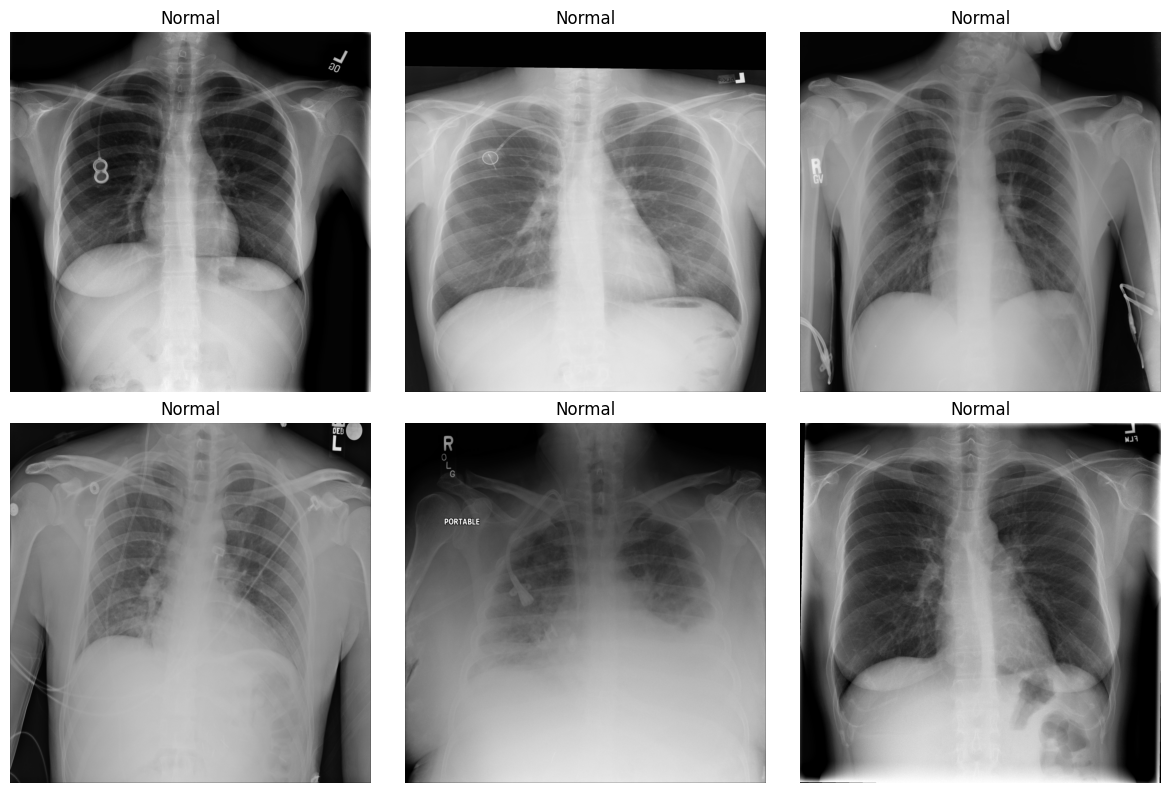

In [172]:
import matplotlib.pyplot as plt
import cv2

samples = df_model.sample(6, random_state=1042).reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Model creation

In [77]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_stage1.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]


In [79]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15


I0000 00:00:1776438802.289309     128 service.cc:152] XLA service 0x7b1dbc00e770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776438802.289362     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776438802.979260     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


   5/1324 ━━━━━━━━━━━━━━━━━━━━ 45s 34ms/step - accuracy: 0.5719 - auc: 0.0000e+00 - loss: 5.4189 - precision: 0.0000e+00 - recall: 0.0000e+00  

I0000 00:00:1776438808.098627     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1324/1324 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.3296 - auc: 0.4954 - loss: 797.4940 - precision: 0.0056 - recall: 0.6762
Epoch 1: val_auc improved from -inf to 0.50000, saving model to best_stage1.keras
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 624s 465ms/step - accuracy: 0.3294 - auc: 0.4954 - loss: 797.0512 - precision: 0.0056 - recall: 0.6764 - val_accuracy: 0.0053 - val_auc: 0.5000 - val_loss: 0.1792 - val_precision: 0.0053 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/15
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.0089 - auc: 0.4878 - loss: 0.1731 - precision: 0.0054 - recall: 0.9901
Epoch 2: val_auc improved from 0.50000 to 0.50005, saving model to best_stage1.keras
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 474s 358ms/step - accuracy: 0.0089 - auc: 0.4878 - loss: 0.1731 - precision: 0.0054 - recall: 0.9900 - val_accuracy: 0.0054 - val_auc: 0.5001 - val_loss: 0.1745 - val_precision: 0.0053 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/15
1324/1324 ━━━━━━━━━━━━━━━

In [80]:
val_true = val_df["label"].values.astype(int)
val_prob = model.predict(val_gen, verbose=1).ravel()

precisions, recalls, thresholds = precision_recall_curve(val_true, val_prob)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_val_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best validation F1:", best_val_f1)


290/290 ━━━━━━━━━━━━━━━━━━━━ 48s 162ms/step
Best threshold: 0.49931815
Best validation F1: 0.010546706739686601


In [81]:
for t in [0.10, 0.20, float(best_threshold), 0.35, 0.50]:
    y_pred = (val_prob >= t).astype(int)
    print(f"\nThreshold = {t:.4f}")
    print(confusion_matrix(val_true, y_pred))
    print(classification_report(val_true, y_pred, digits=4, zero_division=0))



Threshold = 0.1000
[[   0 9207]
 [   0   49]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      9207
           1     0.0053    1.0000    0.0105        49

    accuracy                         0.0053      9256
   macro avg     0.0026    0.5000    0.0053      9256
weighted avg     0.0000    0.0053    0.0001      9256


Threshold = 0.2000
[[   0 9207]
 [   0   49]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      9207
           1     0.0053    1.0000    0.0105        49

    accuracy                         0.0053      9256
   macro avg     0.0026    0.5000    0.0053      9256
weighted avg     0.0000    0.0053    0.0001      9256


Threshold = 0.4993
[[  13 9194]
 [   0   49]]
              precision    recall  f1-score   support

           0     1.0000    0.0014    0.0028      9207
           1     0.0053    1.0000    0.0105        49

    accuracy                         0.00

In [82]:
test_loss, test_auc, test_pr_auc, test_precision, test_recall = model.evaluate(
    test_gen,
    verbose=1
)

print(f"loss: {test_loss:.4f}")
print(f"auc: {test_auc:.4f}")
print(f"pr_auc: {test_pr_auc:.4f}")
print(f"precision@0.5: {test_precision:.4f}")
print(f"recall@0.5: {test_recall:.4f}")


284/284 ━━━━━━━━━━━━━━━━━━━━ 108s 379ms/step - accuracy: 0.9942 - auc: 0.5001 - loss: 0.1725 - precision: 0.0000e+00 - recall: 0.0000e+00
loss: 0.1725
auc: 0.9948
pr_auc: 0.5003
precision@0.5: 0.0000
recall@0.5: 0.0000


In [83]:
y_true = test_df["label"].values.astype(int)
y_prob = model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= best_threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))


284/284 ━━━━━━━━━━━━━━━━━━━━ 57s 199ms/step
Confusion Matrix:
[[  11 9029]
 [   0   47]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.0012    0.0024      9040
           1     0.0052    1.0000    0.0103        47

    accuracy                         0.0064      9087
   macro avg     0.5026    0.5006    0.0064      9087
weighted avg     0.9949    0.0064    0.0025      9087



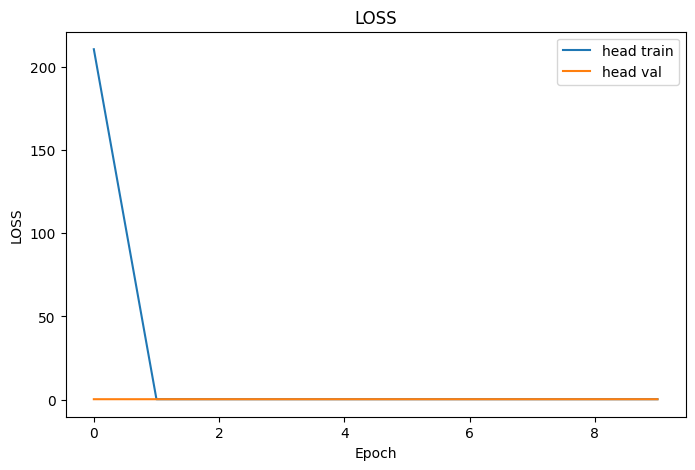

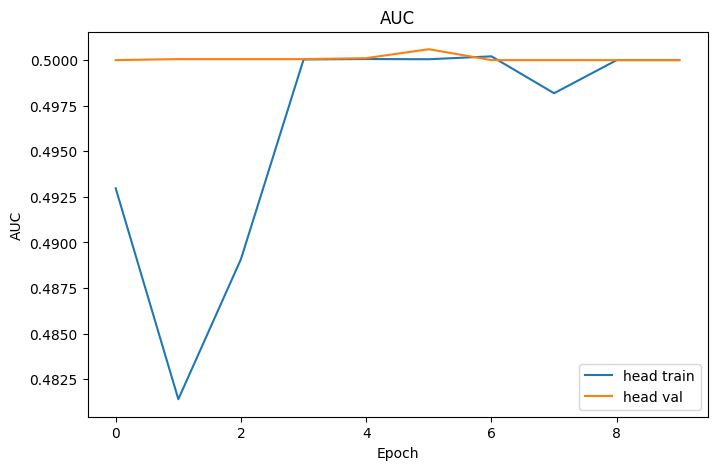

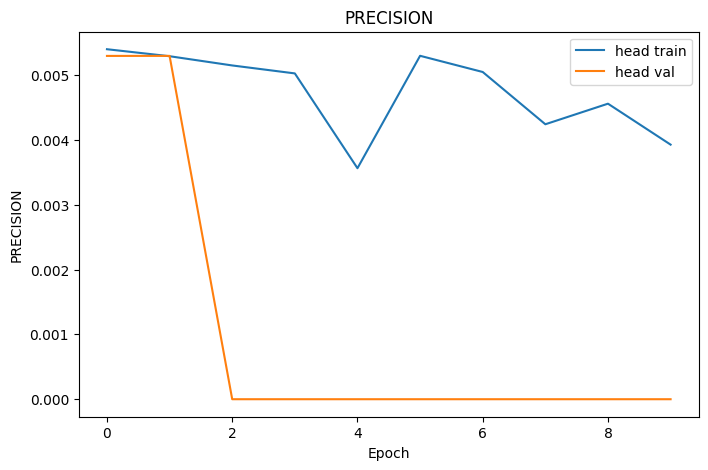

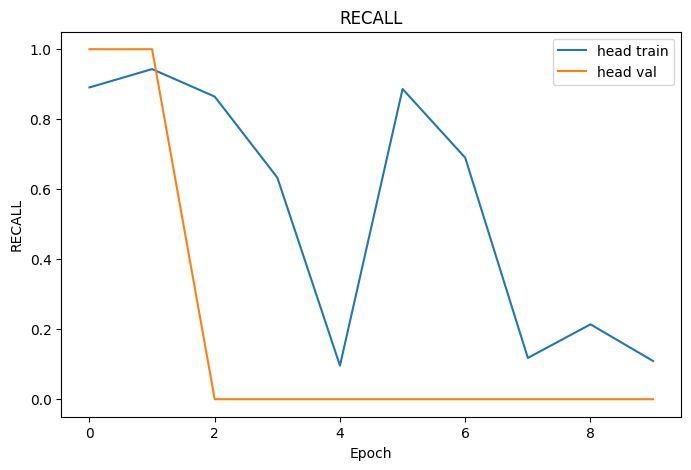

In [87]:
def plot_history(histories, metric="auc"):
    plt.figure(figsize=(8, 5))
    for name, hist in histories.items():
        if metric in hist.history and f"val_{metric}" in hist.history:
            plt.plot(hist.history[metric], label=f"{name} train")
            plt.plot(hist.history[f"val_{metric}"], label=f"{name} val")
    plt.title(metric.upper())
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.show()

histories = {
    "head": history,
}

for metric_name in ["loss", "auc", "precision", "recall"]:
    plot_history(histories, metric_name)


# LIME

In [148]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

In [150]:
def predict_fn(images):
    images = np.array(images)
    return np.concatenate([1 - model.predict(images), model.predict(images)], axis=1)

In [151]:
sample_path = val_df.sample(1)['path'].values[0]

img = Image.open(sample_path).convert("RGB").resize((224, 224))
img_array = np.array(img) / 255.0

explanation = explainer.explain_instance(
    img_array.astype('double'),
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

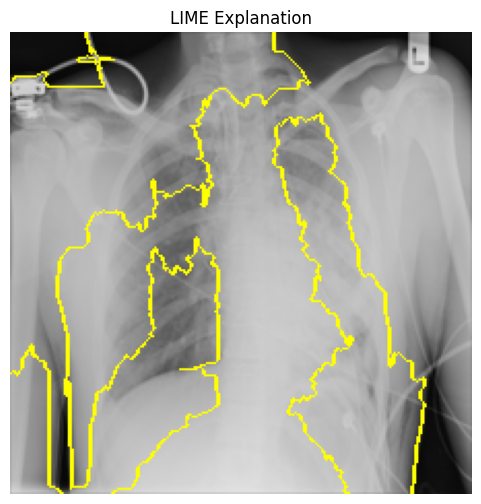

In [152]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()

In [157]:
orig_pred = model.predict(np.expand_dims(img_array, axis=0))[0][0]
print("Original prediction:", orig_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
Original prediction: 0.50117445


In [158]:
# keep only important regions
important_only = img_array.copy()
important_only[mask == 0] = 0

important_pred = model.predict(np.expand_dims(important_only, axis=0))[0][0]

print("Prediction with important regions:", important_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction with important regions: 0.5010813


In [159]:
# remove important regions
removed = img_array.copy()
removed[mask == 1] = 0

removed_pred = model.predict(np.expand_dims(removed, axis=0))[0][0]

print("Prediction without important regions:", removed_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction without important regions: 0.49931815


In [160]:
decision_impact = abs(orig_pred - removed_pred)
confidence_impact = abs(orig_pred - important_pred)

print("Decision Impact:", decision_impact)
print("Confidence Impact:", confidence_impact)

Decision Impact: 0.0018562973
Confidence Impact: 9.316206e-05


Removing “important” regions didn’t matter
Explanation is probably wrong

In [162]:
conf_impacts = []
dec_impacts = []
faith_scores = []

for i in range(50):

    sample_path = val_df.iloc[i]['path']

    img = Image.open(sample_path).convert("RGB").resize((224,224))
    img_array = np.array(img) / 255.0

    pred = model.predict(np.expand_dims(img_array, axis=0))[0][0]

    explanation = explainer.explain_instance(
        img_array.astype('double'),
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=500
    )

    _, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    perturbed = img_array.copy()
    perturbed[mask == 0] = 0

    perturbed_pred = model.predict(np.expand_dims(perturbed, axis=0))[0][0]

    conf_impacts.append(abs(pred - perturbed_pred))
    dec_impacts.append(int((pred > 0.5) != (perturbed_pred > 0.5)))
    faith_scores.append(pred - perturbed_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

In [163]:
print("Mean Confidence Impact:", np.mean(conf_impacts))
print("Mean Decision Impact:", np.mean(dec_impacts))
print("Mean Faithfulness:", np.mean(faith_scores))

Mean Confidence Impact: 0.00056256296
Mean Decision Impact: 0.0
Mean Faithfulness: 0.00019148826
